# **Convolutional Recurrent Neural Network (CRNN) com Atenção e Robustez Adversarial**

Este notebook implementa uma arquitetura CRNN (Convolutional Recurrent Neural Network) com mecanismo de atenção temporal para classificação de sons urbanos no dataset UrbanSound8K. A arquitetura combina:

- **Camadas Convolucionais**: Para extração de características espectrais (textura espectral)
- **Camadas Recorrentes (Bi-LSTM)**: Para modelação da evolução temporal
- **Mecanismo de Atenção**: Para focar nos segmentos mais informativos do áudio
- **Avaliação de Robustez**: Teste simples contra ataques adversariais DeepFool

A entrada do modelo são **Log-Mel Spectrograms** (128 bandas mel × 128 frames temporais), que parecem superar MFCCs em CNNs em tarefas de classificação de sons ambientais.


## Importação de bibliotecas


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundata
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Para ataques adversariais
try:
    from art.attacks.evasion import DeepFool
    from art.estimators.classification import TensorFlowV2Classifier
    ART_AVAILABLE = True
except ImportError:
    print("Adversarial Robustness Toolbox (ART) não está instalado. Instale com: pip install adversarial-robustness-toolbox")
    ART_AVAILABLE = False


## Parâmetros de Pré-processamento

Seguindo as recomendações do relatório técnico, utilizamos:
- **Taxa de amostragem**: 22.050 Hz
- **Duração**: 4 segundos
- **Log-Mel Spectrogram**: 128 bandas mel, FFT size 2048, Hop length 512
- **Dimensões finais**: 128 (frequência) × 128 (tempo)


In [15]:
SAMPLE_RATE = 22050
DURATION = 4
SAMPLES_PER_CLIP = int(SAMPLE_RATE * DURATION)

# Parâmetros para Log-Mel Spectrogram
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
N_TIME_FRAMES = 128  # Número de frames temporais desejados

print(f"Parâmetros configurados:")
print(f"  Sample Rate: {SAMPLE_RATE} Hz")
print(f"  Duração: {DURATION} segundos")
print(f"  Samples por clip: {SAMPLES_PER_CLIP}")
print(f"  Mel bands: {N_MELS}")
print(f"  FFT size: {N_FFT}")
print(f"  Hop length: {HOP_LENGTH}")
print(f"  Time frames: {N_TIME_FRAMES}")


Parâmetros configurados:
  Sample Rate: 22050 Hz
  Duração: 4 segundos
  Samples por clip: 88200
  Mel bands: 128
  FFT size: 2048
  Hop length: 512
  Time frames: 128


## Carregar Dataset e Pré-processar Log-Mel Spectrograms

Vamos carregar o dataset UrbanSound8K e extrair Log-Mel Spectrograms para cada áudio.


In [16]:
# Carregar dataset - usar caminho local
# O dataset está na pasta UrbanSound8K dentro do diretório do projeto
dataset_path = os.path.join(os.getcwd(), "UrbanSound8K")

# Verificar se o diretório existe
if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Diretório do dataset não encontrado: {dataset_path}\n"
        f"Certifique-se de que o dataset UrbanSound8K está na pasta do projeto."
    )

metadata_path = os.path.join(dataset_path, "metadata", "UrbanSound8K.csv")

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"Ficheiro de metadados não encontrado: {metadata_path}\n"
        f"Certifique-se de que o dataset foi descarregado corretamente."
    )

metadata = pd.read_csv(metadata_path)

def get_file_path(row):
    fold = f"fold{row['fold']}"
    file_name = row["slice_file_name"]
    return os.path.join(dataset_path, "audio", fold, file_name)

metadata["file_path"] = metadata.apply(get_file_path, axis=1)

print(f"Dataset carregado: {len(metadata)} amostras")
print(f"Caminho do dataset: {dataset_path}")
print(f"Classes: {metadata['class'].unique()}")
metadata.head()


Dataset carregado: 8732 amostras
Caminho do dataset: /Users/gabrieltxc/Desktop/Home/Partilha/IACD/Ano3/Aprendizagem Computacional 2/Projeto1/UrbanSound8K
Classes: ['dog_bark' 'children_playing' 'car_horn' 'air_conditioner' 'street_music'
 'gun_shot' 'siren' 'engine_idling' 'jackhammer' 'drilling']


,slice_file_name,fsID,start,end,salience,fold,classID,class,file_path
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,/Users/gabrieltxc/Desktop/Home/Partilha/IACD/A...
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,/Users/gabrieltxc/Desktop/Home/Partilha/IACD/A...
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,/Users/gabrieltxc/Desktop/Home/Partilha/IACD/A...
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,/Users/gabrieltxc/Desktop/Home/Partilha/IACD/A...
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,/Users/gabrieltxc/Desktop/Home/Partilha/IACD/A...


In [17]:
def load_audio(path):
    """Carrega e normaliza áudio para duração fixa de 4 segundos"""
    y, sample_rate = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    
    # Garantir duração de 4 segundos
    if len(y) > SAMPLES_PER_CLIP:
        y = y[:SAMPLES_PER_CLIP]
    elif len(y) < SAMPLES_PER_CLIP:
        y = np.pad(y, (0, SAMPLES_PER_CLIP - len(y)))
    
    return y

def extract_log_mel_spectrogram(y, sr=SAMPLE_RATE):
    """
    Extrai Log-Mel Spectrogram do sinal de áudio.
    Retorna um array de dimensão (n_mels, n_time_frames)
    """
    # Calcular Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmax=sr/2
    )
    
    # Converter para decibéis (escala logarítmica)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalizar para [0, 1]
    log_mel_spec = (log_mel_spec - log_mel_spec.min()) / (log_mel_spec.max() - log_mel_spec.min() + 1e-8)
    
    # Redimensionar para ter exatamente N_TIME_FRAMES frames temporais
    if log_mel_spec.shape[1] > N_TIME_FRAMES:
        # Truncar
        log_mel_spec = log_mel_spec[:, :N_TIME_FRAMES]
    elif log_mel_spec.shape[1] < N_TIME_FRAMES:
        # Padding temporal
        pad_width = N_TIME_FRAMES - log_mel_spec.shape[1]
        log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
    
    return log_mel_spec

# Testar função
test_audio = load_audio(metadata.iloc[0]["file_path"])
test_spec = extract_log_mel_spectrogram(test_audio)
print(f"Shape do Log-Mel Spectrogram: {test_spec.shape}")
print(f"Valores min/max: {test_spec.min():.4f} / {test_spec.max():.4f}")


Shape do Log-Mel Spectrogram: (128, 128)
Valores min/max: 0.0000 / 1.0000


## Data Augmentation

Aplicamos técnicas de aumento de dados conforme o relatório:
- **White noise**: Adição de ruído gaussiano
- **Pitch shifting**: Alteração do tom
- **Time stretching**: Alteração da velocidade


In [18]:
def augment_audio(y, sr=SAMPLE_RATE):
    """Gera versões aumentadas do áudio"""
    aug_signals = []
    
    # White noise
    noise_level = np.random.uniform(0.01, 0.05)
    noise = np.random.normal(0, 1, len(y))
    y_noisy = y + noise_level * noise
    aug_signals.append(y_noisy)
    
    # Pitch shifting
    n_steps = np.random.uniform(-4, 4)
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    aug_signals.append(y_pitch)
    
    # Time stretching
    stretch_rate = np.random.uniform(0.8, 1.25)
    y_stretch = librosa.effects.time_stretch(y, rate=stretch_rate)
    aug_signals.append(y_stretch)
    
    # Garantir duração fixa
    processed = []
    for sig in aug_signals:
        if len(sig) > SAMPLES_PER_CLIP:
            sig = sig[:SAMPLES_PER_CLIP]
        elif len(sig) < SAMPLES_PER_CLIP:
            sig = np.pad(sig, (0, SAMPLES_PER_CLIP - len(sig)))
        processed.append(sig)
    
    return processed


## Extrair e Salvar Log-Mel Spectrograms

Processamos todos os áudios e geramos os Log-Mel Spectrograms (originais + aumentados).


In [19]:
PROCESSED_DIR = "processed_data"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Verificar se já existem dados processados
spec_file = os.path.join(PROCESSED_DIR, "X_crnn_logmel.npy")
labels_file = os.path.join(PROCESSED_DIR, "y_labels_crnn.npy")
folds_file = os.path.join(PROCESSED_DIR, "folds_crnn.npy")

if os.path.exists(spec_file) and os.path.exists(labels_file) and os.path.exists(folds_file):
    print("Carregando dados pré-processados existentes...")
    X_crnn = np.load(spec_file)
    y = np.load(labels_file)
    folds = np.load(folds_file)
    print(f"Dados carregados: X shape = {X_crnn.shape}, y shape = {y.shape}")
else:
    print("Processando áudios e extraindo Log-Mel Spectrograms...")
    X_crnn_list = []
    y_list = []
    fold_list = []
    
    for idx, row in metadata.iterrows():
        if (idx + 1) % 100 == 0:
            print(f"Processando {idx + 1}/{len(metadata)}...")
        
        file_path = row["file_path"]
        label = row["classID"]
        fold = row["fold"]
        
        # Áudio original
        y_audio = load_audio(file_path)
        spec_orig = extract_log_mel_spectrogram(y_audio)
        X_crnn_list.append(spec_orig)
        y_list.append(label)
        fold_list.append(fold)
        
        # Áudios aumentados
        y_aug_list = augment_audio(y_audio, sr=SAMPLE_RATE)
        for y_aug in y_aug_list:
            spec_aug = extract_log_mel_spectrogram(y_aug)
            X_crnn_list.append(spec_aug)
            y_list.append(label)
            fold_list.append(fold)
    
    X_crnn = np.array(X_crnn_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    folds = np.array(fold_list, dtype=np.int64)
    
    # Adicionar dimensão de canal para CNN (batch, height, width, channels)
    X_crnn = np.expand_dims(X_crnn, axis=-1)  # Shape: (n_samples, 128, 128, 1)
    
    # Salvar
    np.save(spec_file, X_crnn)
    np.save(labels_file, y)
    np.save(folds_file, folds)
    
    print(f"Processamento concluído!")
    print(f"X_crnn shape: {X_crnn.shape}")
    print(f"y shape: {y.shape}")
    print(f"folds shape: {folds.shape}")

n_classes = len(np.unique(y))
print(f"\nNúmero de classes: {n_classes}")


Processando áudios e extraindo Log-Mel Spectrograms...
Processando 100/8732...
Processando 200/8732...
Processando 300/8732...
Processando 400/8732...
Processando 500/8732...
Processando 600/8732...
Processando 700/8732...
Processando 800/8732...
Processando 900/8732...
Processando 1000/8732...
Processando 1100/8732...
Processando 1200/8732...
Processando 1300/8732...
Processando 1400/8732...
Processando 1500/8732...
Processando 1600/8732...
Processando 1700/8732...
Processando 1800/8732...
Processando 1900/8732...
Processando 2000/8732...
Processando 2100/8732...
Processando 2200/8732...
Processando 2300/8732...
Processando 2400/8732...
Processando 2500/8732...
Processando 2600/8732...
Processando 2700/8732...
Processando 2800/8732...
Processando 2900/8732...
Processando 3000/8732...
Processando 3100/8732...
Processando 3200/8732...
Processando 3300/8732...
Processando 3400/8732...
Processando 3500/8732...
Processando 3600/8732...
Processando 3700/8732...
Processando 3800/8732...
Proc

## Arquitetura CRNN com Atenção

A arquitetura CRNN combina:
1. **Bloco CNN**: 4 camadas convolucionais para extrair características espectrais
2. **Reshape**: Converte saída da CNN em sequência temporal
3. **Bloco RNN**: Bi-LSTM para modelar evolução temporal
4. **Atenção**: Mecanismo de atenção temporal para focar em segmentos relevantes
5. **Classificador**: Camadas densas para predição final


In [20]:
class TemporalAttention(layers.Layer):
    """
    Mecanismo de atenção temporal que aprende a focar nos segmentos mais informativos
    da sequência temporal.
    """
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)
    
    def build(self, input_shape):
        # input_shape: (batch, time_steps, features)
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)
    
    def call(self, x):
        # x shape: (batch, time_steps, features)
        # Calcular scores de atenção
        e = tf.tensordot(x, self.W, axes=[2, 0])  # (batch, time_steps, 1)
        e = tf.squeeze(e, axis=-1) + self.b  # (batch, time_steps)
        e = tf.nn.tanh(e)
        
        # Aplicar softmax para obter pesos de atenção
        a = tf.nn.softmax(e, axis=1)  # (batch, time_steps)
        a = tf.expand_dims(a, axis=-1)  # (batch, time_steps, 1)
        
        # Aplicar pesos e somar
        weighted_output = tf.reduce_sum(x * a, axis=1)  # (batch, features)
        
        return weighted_output
    
    def get_config(self):
        config = super().get_config()
        return config


In [21]:
def build_crnn_attention_model(input_shape, n_classes, dropout_rate=0.5, learning_rate=1e-3, l2_reg=1e-4):
    """
    Constrói arquitetura CRNN com atenção.
    
    Usa pooling assimétrico para preservar mais informação temporal:
    - Mais agressivo em frequência (reduz resolução espectral)
    - Menos agressivo em tempo (preserva frames temporais)
    
    Args:
        input_shape: Shape da entrada (height, width, channels) - ex: (128, 128, 1)
        n_classes: Número de classes
        dropout_rate: Taxa de dropout
        learning_rate: Taxa de aprendizagem
        l2_reg: Regularização L2
    
    Returns:
        Modelo compilado
    """
    inputs = layers.Input(shape=input_shape)
    
    # ========== BLOCO CNN ==========
    # Conv Block 1 - pooling mais agressivo em frequência
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((4, 2))(x)  # (32, 64, 64) - reduz mais em freq
    x = layers.Dropout(0.25)(x)
    
    # Conv Block 2
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # (16, 32, 128)
    x = layers.Dropout(0.25)(x)
    
    # Conv Block 3
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # (8, 16, 256)
    x = layers.Dropout(0.25)(x)
    
    # Conv Block 4
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)  # (4, 16, 512) - reduz pouco em tempo
    x = layers.Dropout(0.25)(x)
    
    # ========== RESHAPE PARA RNN ==========
    # Reshape: (time_steps, features)
    # time_steps = 4, features = 16 * 512 = 8192
    x = layers.Reshape((4, 16 * 512))(x)  # (4, 8192)
    
    # Reduzir dimensionalidade antes da RNN
    x = layers.Dense(256, activation='relu')(x)  # (4, 256)
    
    # ========== BLOCO RNN ==========
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                          kernel_regularizer=l2(l2_reg)))(x)
    x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True,
                                          kernel_regularizer=l2(l2_reg)))(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # ========== ATENÇÃO ==========
    attention = TemporalAttention()
    x = attention(x)  # (batch, 128) - 128 = 2 * 64 (bidirectional)
    
    # ========== CLASSIFICADOR ==========
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # Compilar
    optimizer = optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Criar modelo
input_shape = (N_MELS, N_TIME_FRAMES, 1)
model = build_crnn_attention_model(input_shape, n_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 16, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 16, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 16, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 16, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 8192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4, 256)         │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 4, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 4, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 128)         │             

 Total params: 4,235,211 (16.16 MB)

 Trainable params: 4,233,291 (16.15 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Hiperparâmetros e Callbacks


In [22]:
learning_rate = 1e-3
dropout_rate = 0.5
l2_reg = 1e-4
batch_size = 32
epochs = 50

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

callback_list = [early_stop, reduce_lr]


## Treino com Validação Cruzada de 10 Folds

Seguindo o protocolo oficial do UrbanSound8K, realizamos validação cruzada de 10 folds, respeitando a divisão fornecida pelo dataset para evitar data leakage.


In [23]:
class_names = ["air-conditioner", "car-horn", "children-playing", "dog-bark", 
               "drilling", "engine-idling", "gun-shot", "jackhammer", 
               "siren", "street-music"]

def plot_graphs(history, y_true, y_pred, class_labels):
    """Visualiza métricas de treino e matriz de confusão"""
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)

    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=axs[2])
    axs[2].set_title('Confusion Matrix')
    axs[2].set_xlabel('Predicted')
    axs[2].set_ylabel('True')
    plt.setp(axs[2].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()



=== Training Fold 1 (Validation Fold 2) ===
Train samples: 27884
Validation samples: 3552
Test samples: 3492
Epoch 1/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 170s 190ms/step - accuracy: 0.2152 - loss: 2.2749 - val_accuracy: 0.1850 - val_loss: 3.8149 - learning_rate: 0.0010
Epoch 2/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - accuracy: 0.3465 - loss: 1.9413 - val_accuracy: 0.2734 - val_loss: 2.0663 - learning_rate: 0.0010
Epoch 3/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - accuracy: 0.3912 - loss: 1.8437 - val_accuracy: 0.3958 - val_loss: 1.7319 - learning_rate: 0.0010
Epoch 4/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 164s 188ms/step - accuracy: 0.4231 - loss: 1.7929 - val_accuracy: 0.2838 - val_loss: 2.8190 - learning_rate: 0.0010
Epoch 5/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 187ms/step - accuracy: 0.4434 - loss: 1.7486 - val_accuracy: 0.4017 - val_loss: 1.9075 - learning_rate: 0.0010
Epoch 6/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 164s 188ms/step - accuracy: 0.4665 - loss: 1.7268 - val_accuracy: 0.47

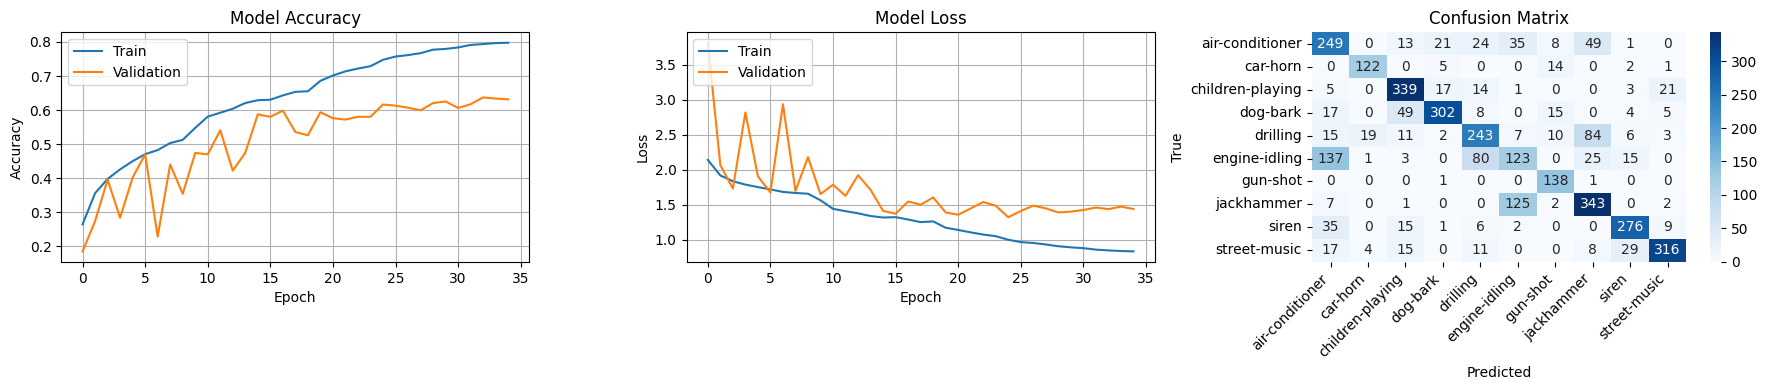


=== Training Fold 2 (Validation Fold 3) ===
Train samples: 27676
Validation samples: 3700
Test samples: 3552
Epoch 1/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 171s 193ms/step - accuracy: 0.2030 - loss: 2.3046 - val_accuracy: 0.2932 - val_loss: 1.9721 - learning_rate: 0.0010
Epoch 2/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 165s 191ms/step - accuracy: 0.3009 - loss: 2.0264 - val_accuracy: 0.3438 - val_loss: 1.9278 - learning_rate: 0.0010
Epoch 3/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 163s 188ms/step - accuracy: 0.3511 - loss: 1.9231 - val_accuracy: 0.3519 - val_loss: 1.8330 - learning_rate: 0.0010
Epoch 4/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.3780 - loss: 1.8567 - val_accuracy: 0.3716 - val_loss: 1.8072 - learning_rate: 0.0010
Epoch 5/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 163s 188ms/step - accuracy: 0.3860 - loss: 1.8289 - val_accuracy: 0.3881 - val_loss: 1.9054 - learning_rate: 0.0010
Epoch 6/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.4081 - loss: 1.8034 - val_accuracy: 0.42

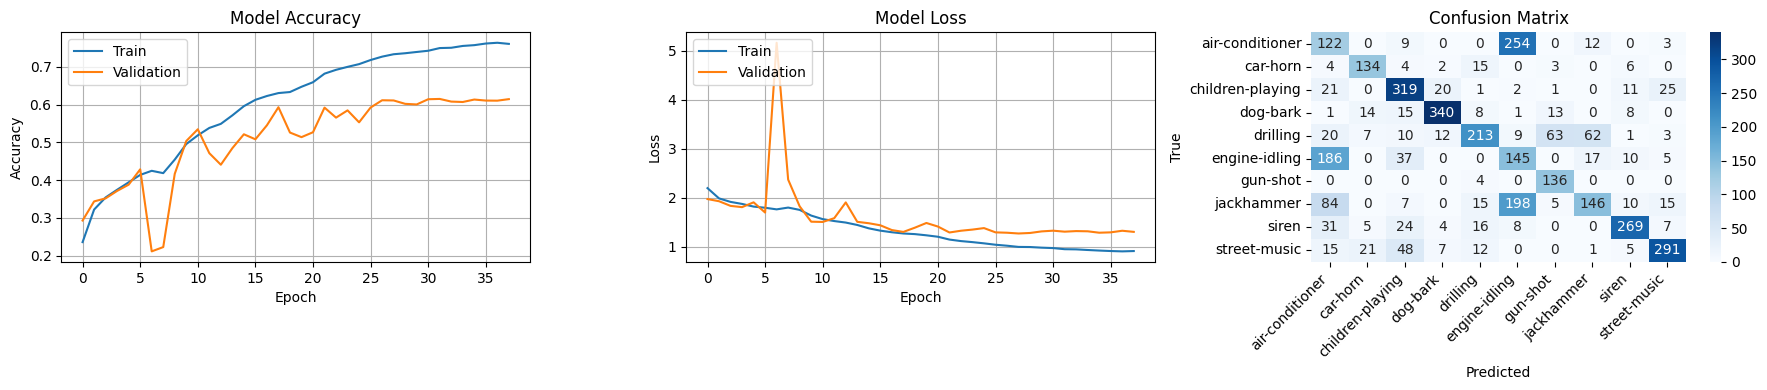


=== Training Fold 3 (Validation Fold 4) ===
Train samples: 27268
Validation samples: 3960
Test samples: 3700
Epoch 1/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - accuracy: 0.2199 - loss: 2.2556 - val_accuracy: 0.0980 - val_loss: 3.5155 - learning_rate: 0.0010
Epoch 2/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 161s 188ms/step - accuracy: 0.3077 - loss: 1.9745 - val_accuracy: 0.2126 - val_loss: 2.5002 - learning_rate: 0.0010
Epoch 3/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 160s 188ms/step - accuracy: 0.3672 - loss: 1.8525 - val_accuracy: 0.2581 - val_loss: 2.6642 - learning_rate: 0.0010
Epoch 4/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 160s 188ms/step - accuracy: 0.4060 - loss: 1.8188 - val_accuracy: 0.3187 - val_loss: 1.9715 - learning_rate: 0.0010
Epoch 5/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 161s 188ms/step - accuracy: 0.4292 - loss: 1.7797 - val_accuracy: 0.2111 - val_loss: 2.5784 - learning_rate: 0.0010
Epoch 6/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 160s 188ms/step - accuracy: 0.4356 - loss: 1.7913 - val_accuracy: 0.33

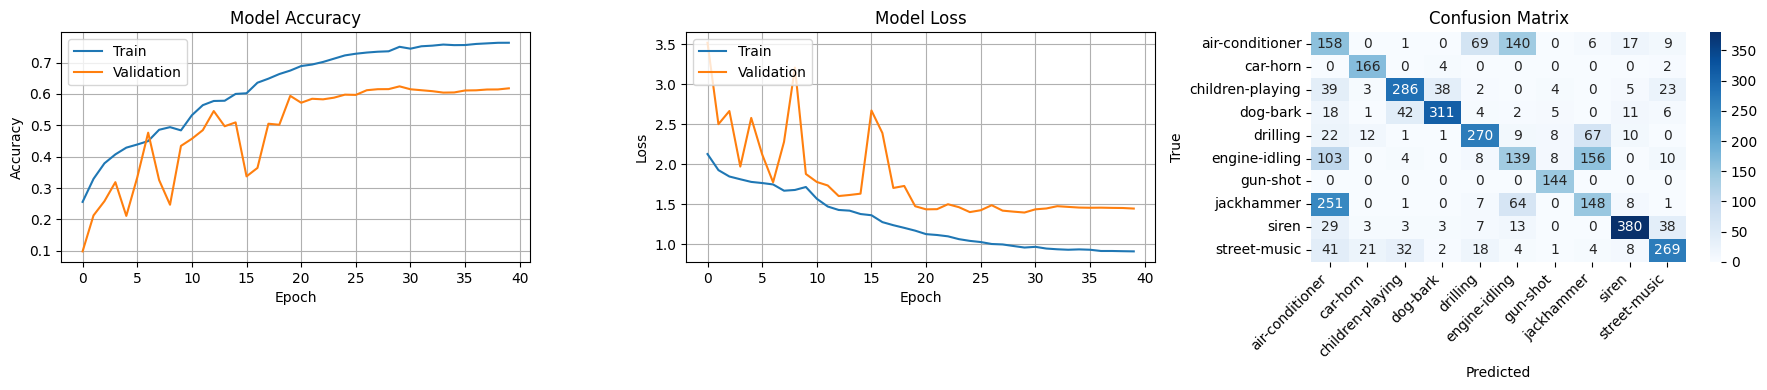


=== Training Fold 4 (Validation Fold 5) ===
Train samples: 27224
Validation samples: 3744
Test samples: 3960
Epoch 1/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - accuracy: 0.2171 - loss: 2.2632 - val_accuracy: 0.3285 - val_loss: 1.9671 - learning_rate: 0.0010
Epoch 2/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 160s 188ms/step - accuracy: 0.3281 - loss: 1.9526 - val_accuracy: 0.3438 - val_loss: 1.9495 - learning_rate: 0.0010
Epoch 3/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 160s 188ms/step - accuracy: 0.3813 - loss: 1.8278 - val_accuracy: 0.3349 - val_loss: 2.2885 - learning_rate: 0.0010
Epoch 4/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 160s 187ms/step - accuracy: 0.4036 - loss: 1.7971 - val_accuracy: 0.3758 - val_loss: 1.9431 - learning_rate: 0.0010
Epoch 5/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 159s 187ms/step - accuracy: 0.4195 - loss: 1.7611 - val_accuracy: 0.3590 - val_loss: 1.8224 - learning_rate: 0.0010
Epoch 6/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 159s 187ms/step - accuracy: 0.4496 - loss: 1.7133 - val_accuracy: 0.41

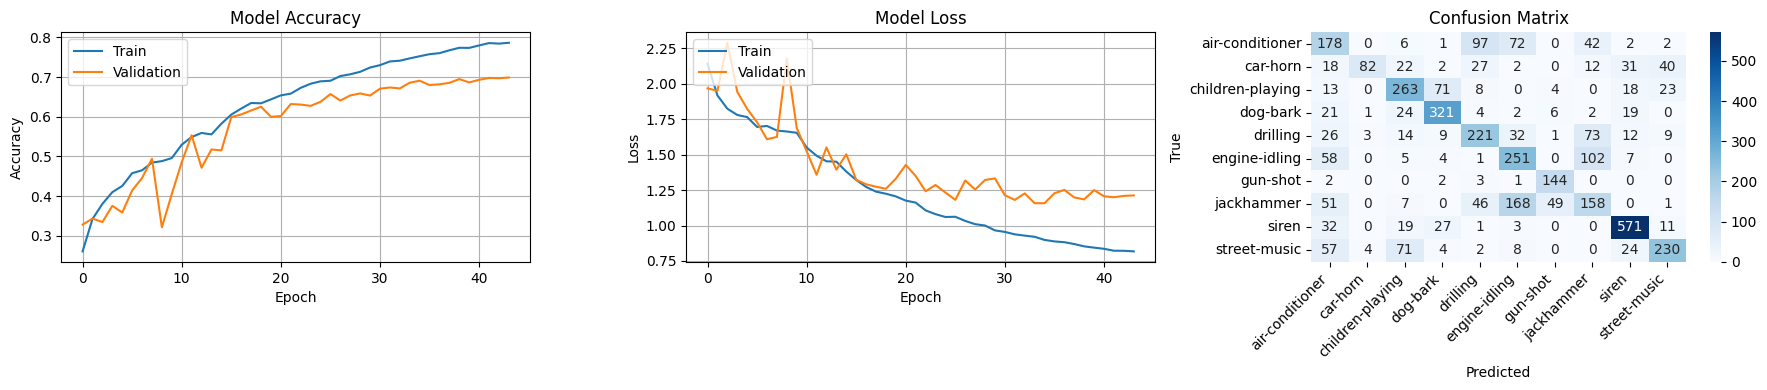


=== Training Fold 5 (Validation Fold 6) ===
Train samples: 27892
Validation samples: 3292
Test samples: 3744
Epoch 1/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 168s 188ms/step - accuracy: 0.2068 - loss: 2.2762 - val_accuracy: 0.1221 - val_loss: 4.0107 - learning_rate: 0.0010
Epoch 2/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 187ms/step - accuracy: 0.3348 - loss: 1.9468 - val_accuracy: 0.4128 - val_loss: 1.7539 - learning_rate: 0.0010
Epoch 3/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 186ms/step - accuracy: 0.3802 - loss: 1.8460 - val_accuracy: 0.3870 - val_loss: 1.7602 - learning_rate: 0.0010
Epoch 4/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 186ms/step - accuracy: 0.4241 - loss: 1.7921 - val_accuracy: 0.3767 - val_loss: 1.8743 - learning_rate: 0.0010
Epoch 5/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 186ms/step - accuracy: 0.4205 - loss: 1.7731 - val_accuracy: 0.4493 - val_loss: 1.7173 - learning_rate: 0.0010
Epoch 6/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 187ms/step - accuracy: 0.4331 - loss: 1.7781 - val_accuracy: 0.38

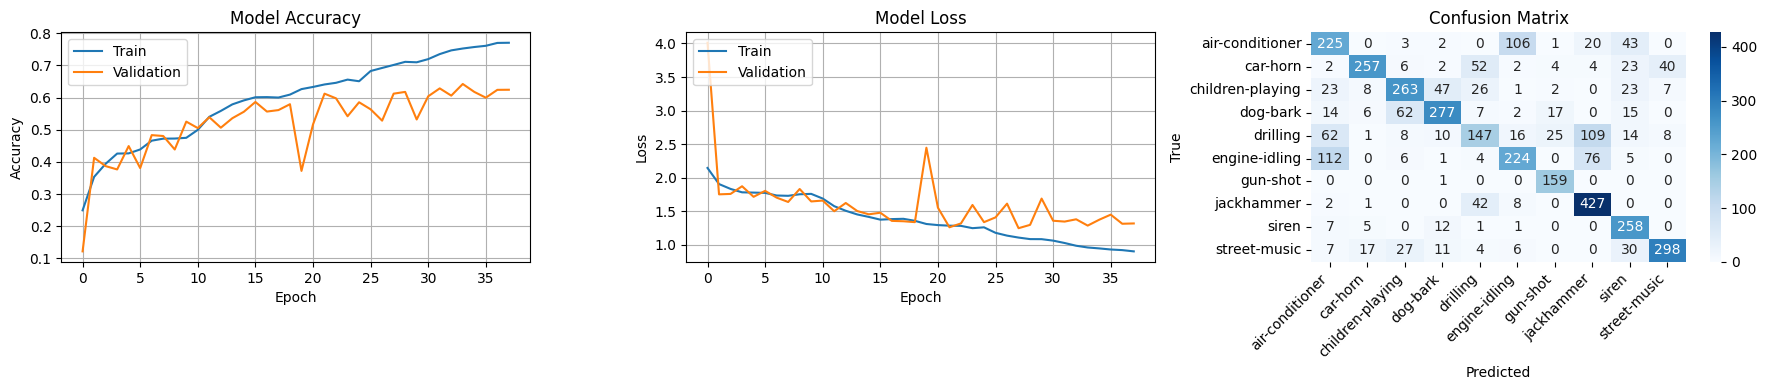


=== Training Fold 6 (Validation Fold 7) ===
Train samples: 28284
Validation samples: 3352
Test samples: 3292
Epoch 1/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 170s 188ms/step - accuracy: 0.2175 - loss: 2.2755 - val_accuracy: 0.3058 - val_loss: 2.1441 - learning_rate: 0.0010
Epoch 2/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 165s 187ms/step - accuracy: 0.3224 - loss: 1.9726 - val_accuracy: 0.3484 - val_loss: 1.9683 - learning_rate: 0.0010
Epoch 3/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 165s 186ms/step - accuracy: 0.3643 - loss: 1.9027 - val_accuracy: 0.3001 - val_loss: 2.2001 - learning_rate: 0.0010
Epoch 4/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 165s 186ms/step - accuracy: 0.3935 - loss: 1.8230 - val_accuracy: 0.3073 - val_loss: 2.2073 - learning_rate: 0.0010
Epoch 5/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.3897 - loss: 1.8534
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
884/884 ━━━━━━━━━━━━━━━━━━━━ 165s 186ms/step - accuracy: 0.3897 - loss: 1.8534 - val_accuracy: 0.2061 

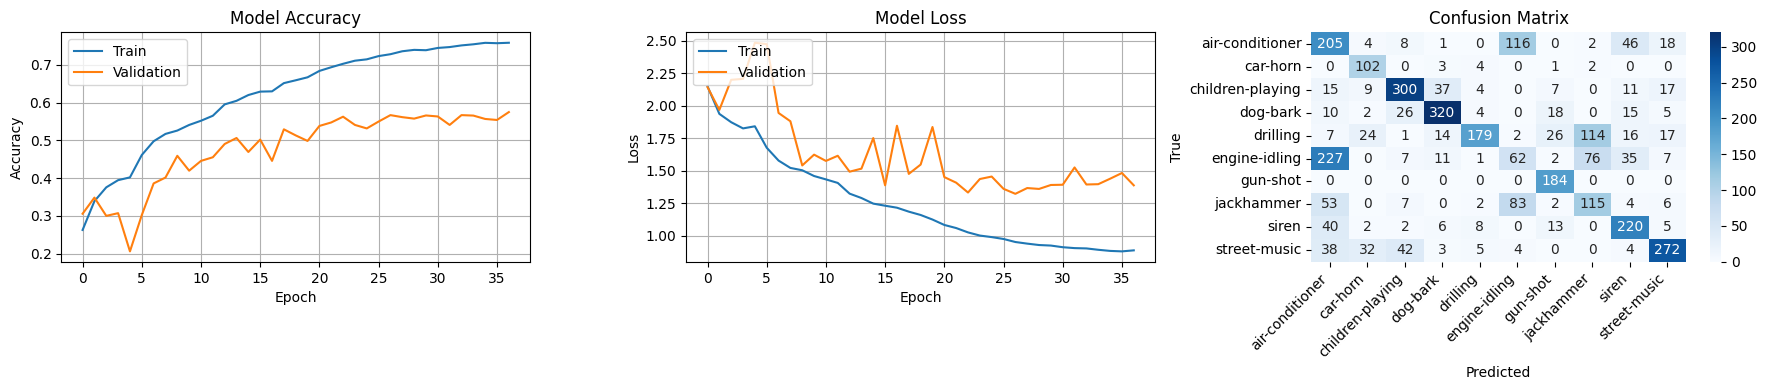


=== Training Fold 7 (Validation Fold 8) ===
Train samples: 28352
Validation samples: 3224
Test samples: 3352
Epoch 1/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 177s 195ms/step - accuracy: 0.2123 - loss: 2.2788 - val_accuracy: 0.1942 - val_loss: 2.5465 - learning_rate: 0.0010
Epoch 2/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 173s 195ms/step - accuracy: 0.3127 - loss: 1.9793 - val_accuracy: 0.3635 - val_loss: 1.7921 - learning_rate: 0.0010
Epoch 3/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 170s 192ms/step - accuracy: 0.3533 - loss: 1.8923 - val_accuracy: 0.4460 - val_loss: 1.6960 - learning_rate: 0.0010
Epoch 4/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 168s 190ms/step - accuracy: 0.3951 - loss: 1.8178 - val_accuracy: 0.3437 - val_loss: 1.8823 - learning_rate: 0.0010
Epoch 5/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 168s 189ms/step - accuracy: 0.3840 - loss: 1.8493 - val_accuracy: 0.4293 - val_loss: 1.6900 - learning_rate: 0.0010
Epoch 6/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 170s 191ms/step - accuracy: 0.4256 - loss: 1.7534 - val_accuracy: 0.43

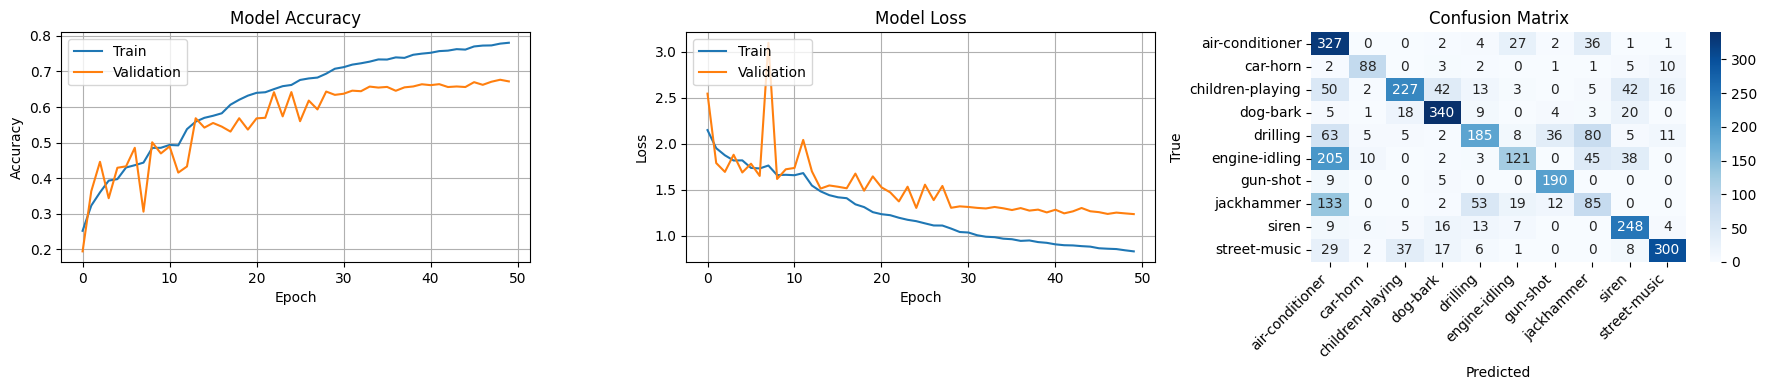


=== Training Fold 8 (Validation Fold 9) ===
Train samples: 28440
Validation samples: 3264
Test samples: 3224
Epoch 1/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 172s 190ms/step - accuracy: 0.2109 - loss: 2.2793 - val_accuracy: 0.2684 - val_loss: 2.4090 - learning_rate: 0.0010
Epoch 2/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 167s 188ms/step - accuracy: 0.3467 - loss: 1.9184 - val_accuracy: 0.2583 - val_loss: 2.2532 - learning_rate: 0.0010
Epoch 3/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 167s 188ms/step - accuracy: 0.3897 - loss: 1.8231 - val_accuracy: 0.4384 - val_loss: 1.8910 - learning_rate: 0.0010
Epoch 4/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 167s 188ms/step - accuracy: 0.4246 - loss: 1.7547 - val_accuracy: 0.3719 - val_loss: 1.7949 - learning_rate: 0.0010
Epoch 5/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 167s 187ms/step - accuracy: 0.4303 - loss: 1.7535 - val_accuracy: 0.2543 - val_loss: 2.3207 - learning_rate: 0.0010
Epoch 6/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 166s 187ms/step - accuracy: 0.4433 - loss: 1.7671 - val_accuracy: 0.39

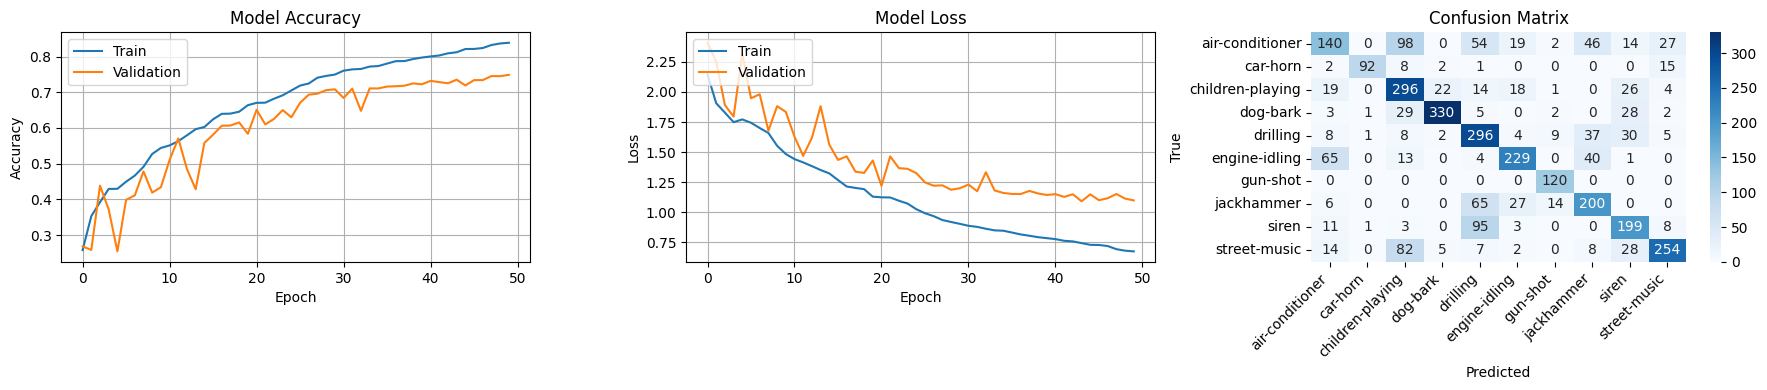


=== Training Fold 9 (Validation Fold 10) ===
Train samples: 28316
Validation samples: 3348
Test samples: 3264
Epoch 1/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 170s 188ms/step - accuracy: 0.2069 - loss: 2.3067 - val_accuracy: 0.2852 - val_loss: 2.0428 - learning_rate: 0.0010
Epoch 2/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 166s 187ms/step - accuracy: 0.3553 - loss: 1.9453 - val_accuracy: 0.2210 - val_loss: 2.4947 - learning_rate: 0.0010
Epoch 3/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 166s 187ms/step - accuracy: 0.3963 - loss: 1.8263 - val_accuracy: 0.3100 - val_loss: 2.0298 - learning_rate: 0.0010
Epoch 4/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 167s 188ms/step - accuracy: 0.4139 - loss: 1.8052 - val_accuracy: 0.3999 - val_loss: 1.8645 - learning_rate: 0.0010
Epoch 5/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 167s 188ms/step - accuracy: 0.4147 - loss: 1.7985 - val_accuracy: 0.3507 - val_loss: 2.0687 - learning_rate: 0.0010
Epoch 6/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 165s 186ms/step - accuracy: 0.4304 - loss: 1.7965 - val_accuracy: 0.4

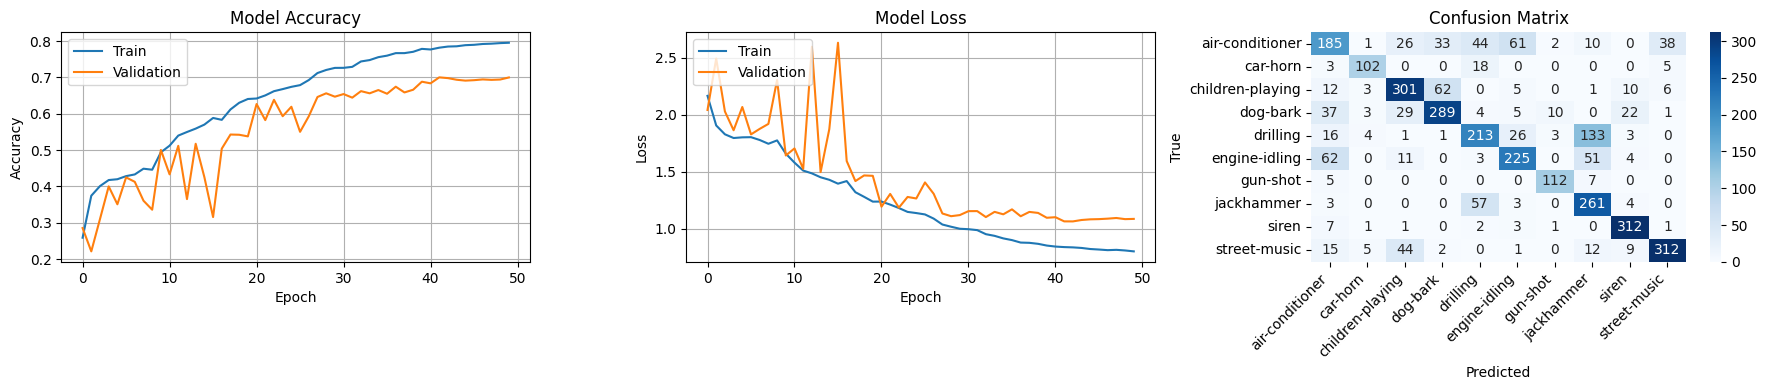


=== Training Fold 10 (Validation Fold 1) ===
Train samples: 28088
Validation samples: 3492
Test samples: 3348
Epoch 1/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 173s 193ms/step - accuracy: 0.2153 - loss: 2.2813 - val_accuracy: 0.1415 - val_loss: 4.0418 - learning_rate: 0.0010
Epoch 2/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 167s 191ms/step - accuracy: 0.3169 - loss: 1.9767 - val_accuracy: 0.3691 - val_loss: 1.8838 - learning_rate: 0.0010
Epoch 3/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 167s 190ms/step - accuracy: 0.3371 - loss: 1.9263 - val_accuracy: 0.3620 - val_loss: 1.9569 - learning_rate: 0.0010
Epoch 4/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 167s 190ms/step - accuracy: 0.3526 - loss: 1.9110 - val_accuracy: 0.2867 - val_loss: 2.3338 - learning_rate: 0.0010
Epoch 5/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 169s 192ms/step - accuracy: 0.3810 - loss: 1.8310 - val_accuracy: 0.4012 - val_loss: 1.8257 - learning_rate: 0.0010
Epoch 6/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 167s 191ms/step - accuracy: 0.3950 - loss: 1.8301 - val_accuracy: 0.4

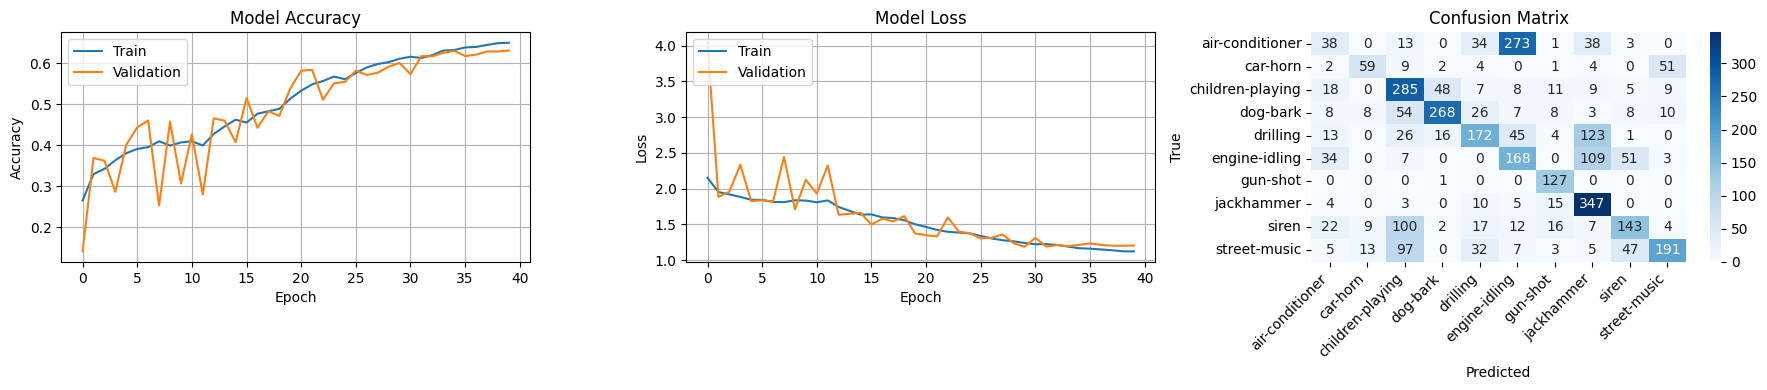


RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION
Fold accuracies: ['0.7019', '0.5954', '0.6138', '0.6109', '0.6771', '0.5951', '0.6298', '0.6687', '0.7083', '0.5370']
Mean accuracy: 0.6338 ± 0.0515


In [24]:
# Inicializar variáveis para armazenar resultados
y_true_all = []
y_pred_all = []
conf_mat = np.zeros((n_classes, n_classes), dtype=np.int64)
fold_accuracies = []
fold_histories = []

# 10-fold cross-validation
for test_fold in range(1, 11):
    val_fold = (test_fold % 10) + 1
    
    # Divisão dos dados
    train_idx = np.where((folds != test_fold) & (folds != val_fold))[0]
    val_idx = np.where(folds == val_fold)[0]
    test_idx = np.where(folds == test_fold)[0]
    
    X_train = X_crnn[train_idx]
    X_val = X_crnn[val_idx]
    X_test = X_crnn[test_idx]
    
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    
    # Criar modelo
    model = build_crnn_attention_model(
        input_shape=(N_MELS, N_TIME_FRAMES, 1),
        n_classes=n_classes,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        l2_reg=l2_reg
    )
    
    print(f"\n{'='*60}")
    print(f"=== Training Fold {test_fold} (Validation Fold {val_fold}) ===")
    print(f"{'='*60}")
    print(f"Train samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    
    # Treinar
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callback_list,
        verbose=1
    )
    
    fold_histories.append(history.history)
    
    # Avaliar no conjunto de teste
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    fold_acc = np.mean(y_pred == y_test)
    fold_accuracies.append(fold_acc)
    print(f"\nFold {test_fold} Test Accuracy: {fold_acc:.4f}")
    
    # Atualizar matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
    conf_mat += cm
    
    # Armazenar predições
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())
    
    # Visualizar resultados do fold
    plot_graphs(history, y_test, y_pred, class_names)

# Resultados finais
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\n{'='*60}")
print("RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION")
print(f"{'='*60}")
print(f"Fold accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")
print(f"Mean accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"{'='*60}")


## Matriz de Confusão Global e Métricas por Classe


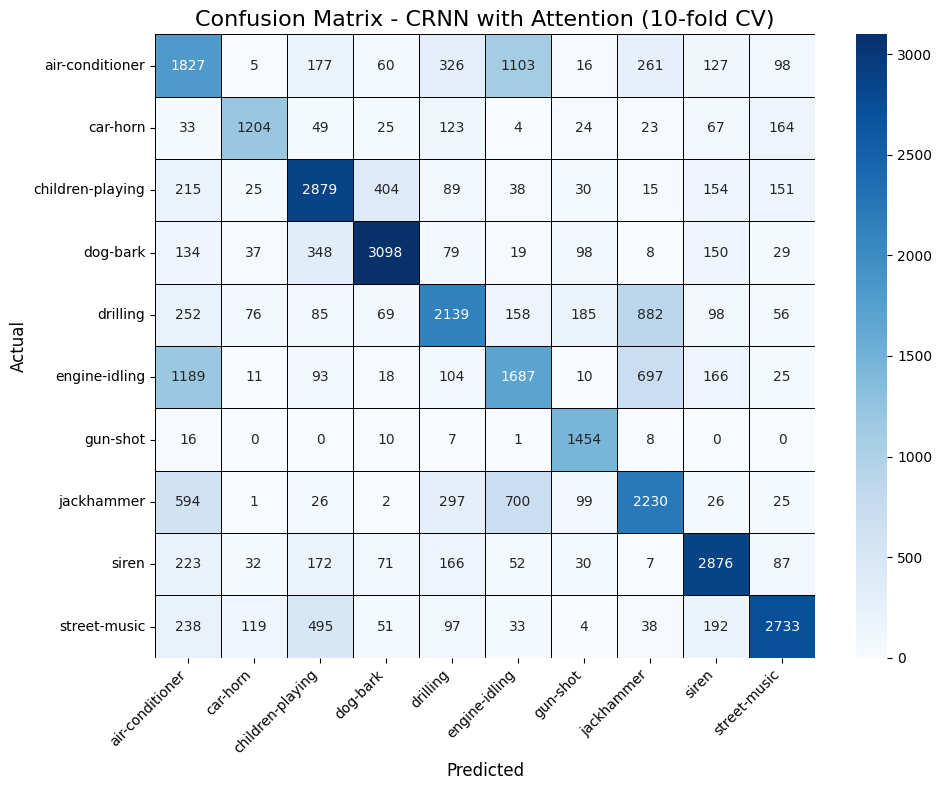


Métricas por Classe:
           Class  Precision   Recall       F1  Support
 air-conditioner   0.386994 0.456750 0.418989     4000
        car-horn   0.797351 0.701632 0.746435     1716
children-playing   0.665819 0.719750 0.691735     4000
        dog-bark   0.813550 0.774500 0.793545     4000
        drilling   0.624161 0.534750 0.576006     4000
   engine-idling   0.444532 0.421750 0.432842     4000
        gun-shot   0.745641 0.971925 0.843877     1496
      jackhammer   0.534900 0.557500 0.545966     4000
           siren   0.745851 0.773950 0.759641     3716
    street-music   0.811461 0.683250 0.741857     4000
   Macro-average   0.657026 0.659576 0.655089    34928


In [25]:
# Matriz de confusão global
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Confusion Matrix - CRNN with Attention (10-fold CV)", fontsize=16)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Métricas por classe
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    average=None
)

macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

df_metrics.loc[len(df_metrics)] = [
    "Macro-average", 
    macro_precision, 
    macro_recall, 
    macro_f1,
    len(y_true_all)
]

print("\nMétricas por Classe:")
print(df_metrics.to_string(index=False))


## Curvas de Aprendizagem (Média sobre Folds)


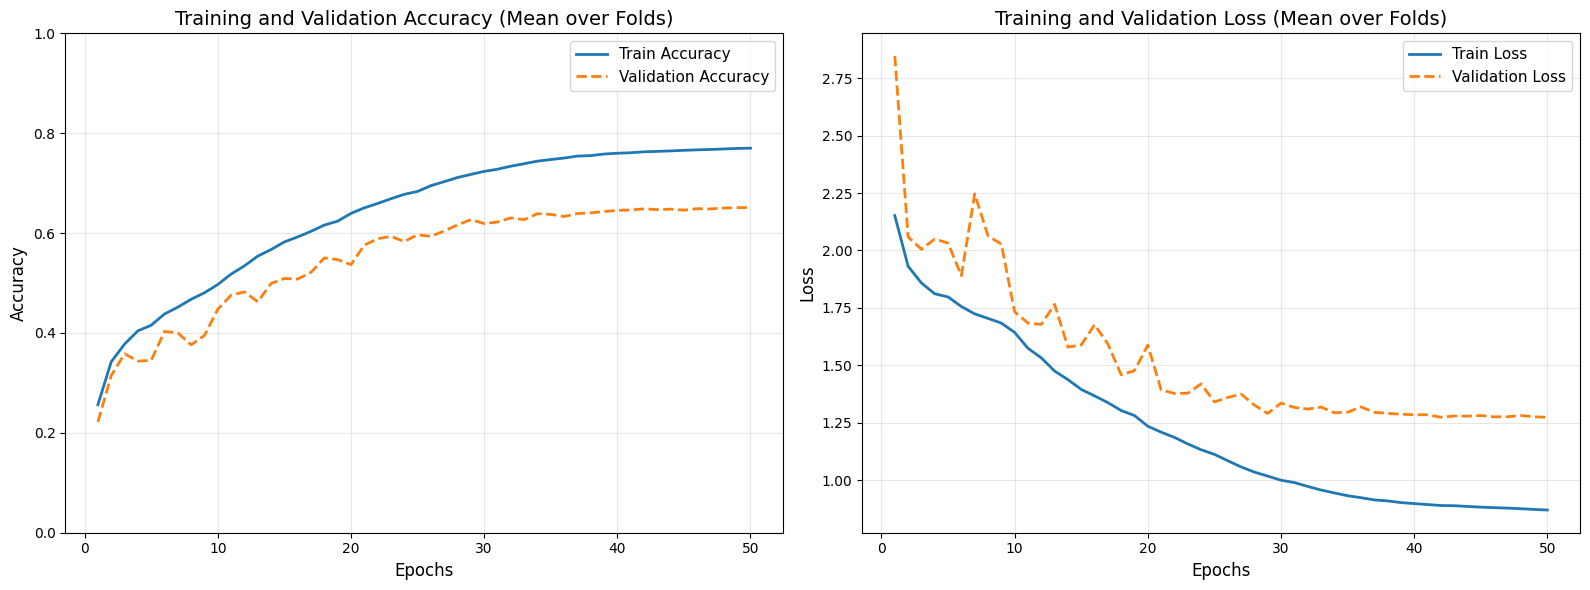

In [26]:
max_epochs = max(len(h["accuracy"]) for h in fold_histories)

def pad(seq, max_len):
    return seq + [seq[-1]] * (max_len - len(seq))

acc_matrix = np.array([pad(h["accuracy"], max_epochs) for h in fold_histories])
val_acc_matrix = np.array([pad(h["val_accuracy"], max_epochs) for h in fold_histories])
loss_matrix = np.array([pad(h["loss"], max_epochs) for h in fold_histories])
val_loss_matrix = np.array([pad(h["val_loss"], max_epochs) for h in fold_histories])

mean_acc = np.mean(acc_matrix, axis=0)
mean_val_acc = np.mean(val_acc_matrix, axis=0)
mean_loss = np.mean(loss_matrix, axis=0)
mean_val_loss = np.mean(val_loss_matrix, axis=0)

epoch_axis = np.arange(1, max_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epoch_axis, mean_acc, label="Train Accuracy", linewidth=2)
ax1.plot(epoch_axis, mean_val_acc, label="Validation Accuracy", linestyle="--", linewidth=2)
ax1.set_title("Training and Validation Accuracy (Mean over Folds)", fontsize=14)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_ylim(0.0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

ax2.plot(epoch_axis, mean_loss, label="Train Loss", linewidth=2)
ax2.plot(epoch_axis, mean_val_loss, label="Validation Loss", linestyle="--", linewidth=2)
ax2.set_title("Training and Validation Loss (Mean over Folds)", fontsize=14)
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


## Avaliação de Robustez contra Ataques Adversariais (DeepFool)

Avaliamos a robustez do modelo contra o ataque DeepFool, que procura a perturbação mínima necessária para enganar o classificador. Um modelo mais robusto exigirá perturbações de maior magnitude para falhar.


Avaliando robustez contra ataques DeepFool...
Nota: Esta avaliação pode demorar bastante tempo.

Treinando modelo para avaliação de robustez...
Epoch 1/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 172s 192ms/step - accuracy: 0.2053 - loss: 2.2965 - val_accuracy: 0.1132 - val_loss: 4.4771 - learning_rate: 0.0010
Epoch 2/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 166s 191ms/step - accuracy: 0.3218 - loss: 1.9406 - val_accuracy: 0.1554 - val_loss: 4.3344 - learning_rate: 0.0010
Epoch 3/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 165s 189ms/step - accuracy: 0.3651 - loss: 1.8668 - val_accuracy: 0.3139 - val_loss: 1.8903 - learning_rate: 0.0010
Epoch 4/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 163s 187ms/step - accuracy: 0.4016 - loss: 1.7898 - val_accuracy: 0.3812 - val_loss: 1.8280 - learning_rate: 0.0010
Epoch 5/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 167s 192ms/step - accuracy: 0.4214 - loss: 1.7859 - val_accuracy: 0.4505 - val_loss: 1.9209 - learning_rate: 0.0010
Epoch 6/30
872/872 ━━━━━━━━━━━━━━━━━━━━ 167s 191ms/step - accuracy: 0.4489 -

DeepFool:   0%|          | 0/50 [00:00<?, ?it/s]


RESULTADOS DE ROBUSTEZ - DEEPFOOL ATTACK
Acurácia original: 0.7900
Acurácia após ataque: 0.1400
Queda de acurácia: 0.6500
Norma média da perturbação (L2): 5.306213


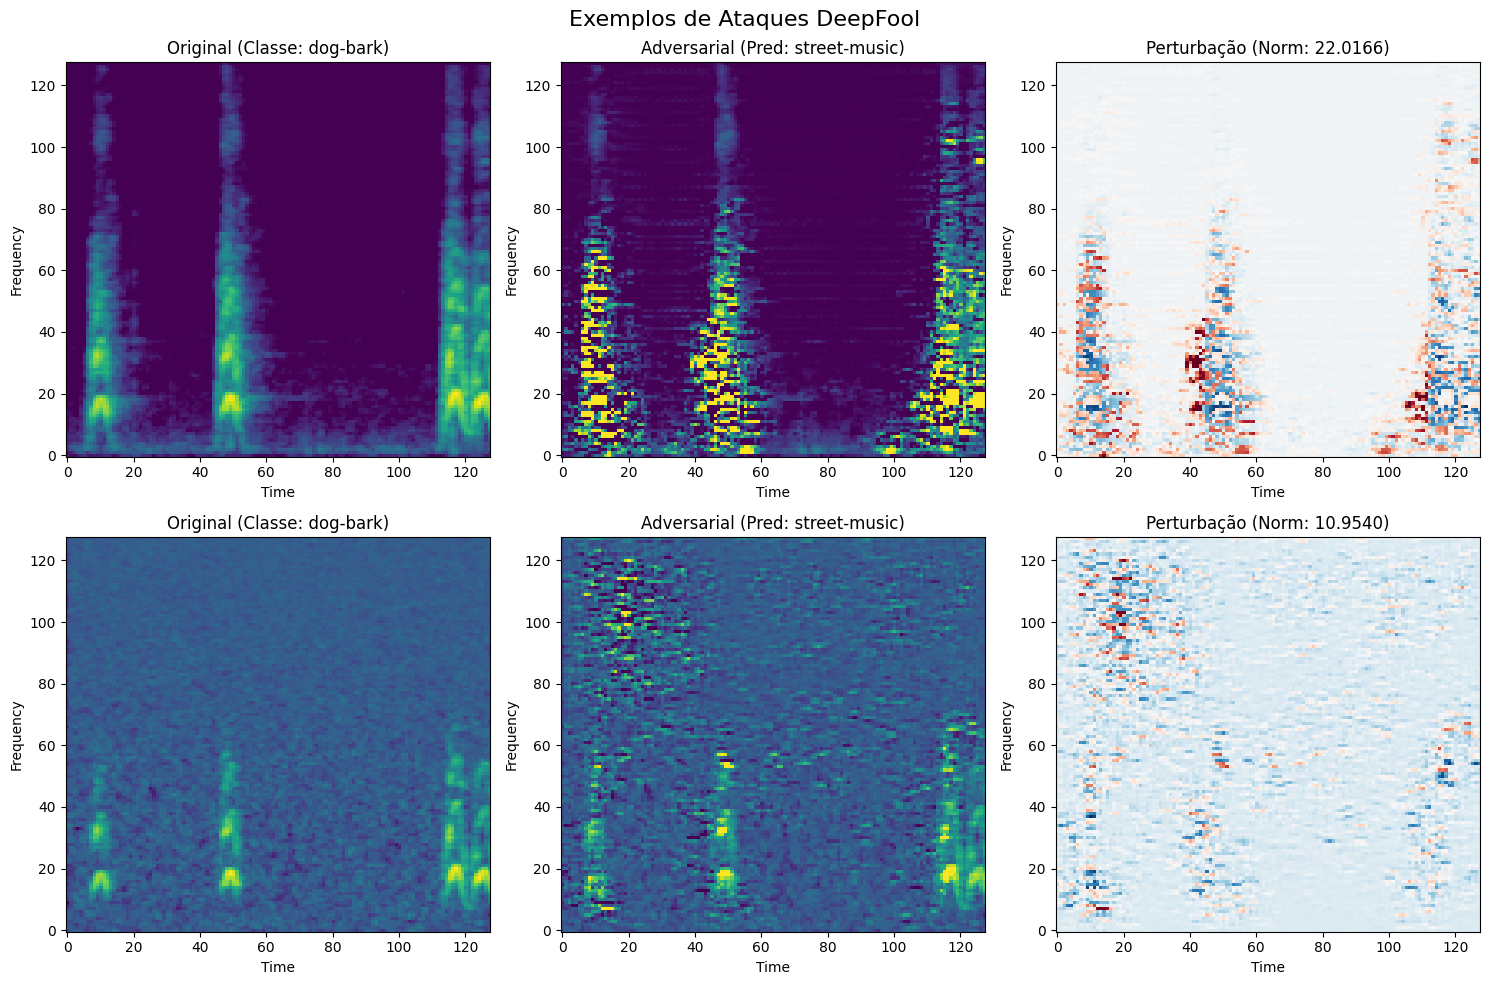

In [27]:
if not ART_AVAILABLE:
    print("ART não está disponível. Pulando avaliação de robustez.")
    print("Para instalar: pip install adversarial-robustness-toolbox")
else:
    print("Avaliando robustez contra ataques DeepFool...")
    print("Nota: Esta avaliação pode demorar bastante tempo.")
    
    # Usar o último fold treinado como exemplo
    # Em produção, deveria avaliar todos os folds
    test_fold = 1
    val_fold = 2
    
    train_idx = np.where((folds != test_fold) & (folds != val_fold))[0]
    val_idx = np.where(folds == val_fold)[0]
    test_idx = np.where(folds == test_fold)[0]
    
    X_train = X_crnn[train_idx]
    X_val = X_crnn[val_idx]
    X_test = X_crnn[test_idx]
    
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    
    # Treinar modelo para avaliação de robustez
    print("\nTreinando modelo para avaliação de robustez...")
    model_robust = build_crnn_attention_model(
        input_shape=(N_MELS, N_TIME_FRAMES, 1),
        n_classes=n_classes,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        l2_reg=l2_reg
    )
    
    model_robust.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,  # Menos épocas para teste rápido
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Avaliar acurácia original
    y_pred_orig = model_robust.predict(X_test[:100], verbose=0)  # Usar apenas 100 amostras para teste
    y_pred_orig = np.argmax(y_pred_orig, axis=1)
    acc_orig = np.mean(y_pred_orig == y_test[:100])
    print(f"\nAcurácia original (100 amostras): {acc_orig:.4f}")
    
    # Criar wrapper para ART
    classifier = TensorFlowV2Classifier(
        model=model_robust,
        nb_classes=n_classes,
        input_shape=(N_MELS, N_TIME_FRAMES, 1),
        loss_object=tf.keras.losses.SparseCategoricalCrossentropy(),
        clip_values=(0, 1)
    )
    
    # Criar ataque DeepFool
    attack = DeepFool(classifier=classifier, max_iter=50, epsilon=1e-6)
    
    print("\nGerando exemplos adversariais com DeepFool...")
    print("(Isso pode demorar vários minutos...)")
    
    # Aplicar ataque em um subconjunto pequeno para teste
    X_test_subset = X_test[:50]  # Usar apenas 50 amostras
    y_test_subset = y_test[:50]
    
    try:
        X_adv = attack.generate(x=X_test_subset)
        
        # Avaliar acurácia em exemplos adversariais
        y_pred_adv = model_robust.predict(X_adv, verbose=0)
        y_pred_adv = np.argmax(y_pred_adv, axis=1)
        acc_adv = np.mean(y_pred_adv == y_test_subset)
        
        # Calcular norma média da perturbação
        perturbations = X_adv - X_test_subset
        perturbation_norms = np.linalg.norm(perturbations.reshape(len(perturbations), -1), axis=1)
        mean_perturbation_norm = np.mean(perturbation_norms)
        
        print(f"\n{'='*60}")
        print("RESULTADOS DE ROBUSTEZ - DEEPFOOL ATTACK")
        print(f"{'='*60}")
        print(f"Acurácia original: {acc_orig:.4f}")
        print(f"Acurácia após ataque: {acc_adv:.4f}")
        print(f"Queda de acurácia: {acc_orig - acc_adv:.4f}")
        print(f"Norma média da perturbação (L2): {mean_perturbation_norm:.6f}")
        print(f"{'='*60}")
        
        # Visualizar perturbações
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Exemplo 1
        idx = 0
        axes[0, 0].imshow(X_test_subset[idx].squeeze(), aspect='auto', origin='lower', cmap='viridis')
        axes[0, 0].set_title(f'Original (Classe: {class_names[y_test_subset[idx]]})')
        axes[0, 0].set_xlabel('Time')
        axes[0, 0].set_ylabel('Frequency')
        
        axes[0, 1].imshow(X_adv[idx].squeeze(), aspect='auto', origin='lower', cmap='viridis')
        axes[0, 1].set_title(f'Adversarial (Pred: {class_names[y_pred_adv[idx]]})')
        axes[0, 1].set_xlabel('Time')
        axes[0, 1].set_ylabel('Frequency')
        
        axes[0, 2].imshow(perturbations[idx].squeeze(), aspect='auto', origin='lower', cmap='RdBu_r')
        axes[0, 2].set_title(f'Perturbação (Norm: {perturbation_norms[idx]:.4f})')
        axes[0, 2].set_xlabel('Time')
        axes[0, 2].set_ylabel('Frequency')
        
        # Exemplo 2
        idx = 1
        axes[1, 0].imshow(X_test_subset[idx].squeeze(), aspect='auto', origin='lower', cmap='viridis')
        axes[1, 0].set_title(f'Original (Classe: {class_names[y_test_subset[idx]]})')
        axes[1, 0].set_xlabel('Time')
        axes[1, 0].set_ylabel('Frequency')
        
        axes[1, 1].imshow(X_adv[idx].squeeze(), aspect='auto', origin='lower', cmap='viridis')
        axes[1, 1].set_title(f'Adversarial (Pred: {class_names[y_pred_adv[idx]]})')
        axes[1, 1].set_xlabel('Time')
        axes[1, 1].set_ylabel('Frequency')
        
        axes[1, 2].imshow(perturbations[idx].squeeze(), aspect='auto', origin='lower', cmap='RdBu_r')
        axes[1, 2].set_title(f'Perturbação (Norm: {perturbation_norms[idx]:.4f})')
        axes[1, 2].set_xlabel('Time')
        axes[1, 2].set_ylabel('Frequency')
        
        plt.suptitle('Exemplos de Ataques DeepFool', fontsize=16)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Erro ao gerar exemplos adversariais: {e}")
        print("Isso pode acontecer devido a problemas de memória ou convergência do ataque.")
